In [7]:
import pandas as pd
import numpy as np
from datetime import timedelta
import random

def generate_emirates_chml_demand_data(start_date='2024-01-01', end_date='2025-12-31'):
    """
    Generates a synthetic dataset for Child Special Meal (CHML) demand 
    forecasting for Emirates GLA-DXB and EDI-DXB routes.
    
    CRITICAL ASSUMPTION: CHML demand is always present (CHML_Ordered >= 1).
    The model now focuses purely on forecasting the QUANTITY based on key factors.
    
    Args:
        start_date (str): Start date for the simulation.
        end_date (str): End date for the simulation.

    Returns:
        pd.DataFrame: A DataFrame with simulated flight and CHML order data.
    """
    
    # --- Configuration Constants ---
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    target_routes = ['GLA-DXB', 'EDI-DXB']
    aircraft_capacity = {'GLA-DXB' : 427, 'EDI-DXB':259} 
    base_load_factor = 0.88
    base_demand_lambda =  {'GLA-DXB' : 21, 'EDI-DXB':15}
    holiday_lamda_effect = {'GLA-DXB' : 19, 'EDI-DXB':13}
    
    data = []

    # Define Scottish School Holiday periods (General simulation) to drive peak demand
    holidays = {
        'Spring_Break_2024': (pd.to_datetime('2024-03-29'), pd.to_datetime('2024-04-14')),
        'Summer_Break_2024': (pd.to_datetime('2024-06-28'), pd.to_datetime('2024-08-12')),
        'Oct_Break_2024': (pd.to_datetime('2024-10-11'), pd.to_datetime('2024-10-27')),
        'Winter_Break_2024': (pd.to_datetime('2024-12-20'), pd.to_datetime('2025-01-05')),
        'Spring_Break_2025': (pd.to_datetime('2025-04-07'), pd.to_datetime('2025-04-18')),
        'Summer_Break_2025': (pd.to_datetime('2025-06-30'), pd.to_datetime('2025-08-14')),
        'Oct_Break_2025': (pd.to_datetime('2025-10-13'), pd.to_datetime('2025-10-17')),
        'Winter_Break_2025': (pd.to_datetime('2025-12-22'), pd.to_datetime('2026-01-05')),
    
    }
    
    # --- Simulation Loop ---
    for date in date_range:
        
        for route in target_routes:
            
            # 1. Base Predictors
            
            # Load Factor: Add random noise, slightly higher on weekends/holidays
            load_factor_noise = np.random.normal(0, 0.03) 
            is_weekend = date.weekday() >= 5 
            load_factor = base_load_factor + load_factor_noise + (0.02 if is_weekend else 0)
            load_factor = np.clip(load_factor, 0.80, 1.0) 
            actual_pax = int(aircraft_capacity[route]* load_factor)
            
            # Check for holidays (The single biggest driver for CHML volume)
            is_holiday = any(start <= date <= end for start, end in holidays.values())
            
            
            # 2. Demand Quantity Calculation (Pure Regression Logic)
            
            
            # Initialize dynamic lambda
            demand_lambda = base_demand_lambda[route]
            
            # Adjust lambda based on key factors found in your domain knowledge:
            
            # Weekend Uplift: Families prefer to travel on weekends
            if is_weekend:
                demand_lambda += 0
            
            # Holiday Uplift: Massive increase during school breaks
            if is_holiday:
                demand_lambda += holiday_lamda_effect[route] # Additive effect for peak travel
            
            # Random daily fluctuation
            demand_lambda += np.random.uniform(-12, 12) 

            # Calculate the CHML orders using Poisson distribution
            chml_ordered = np.random.poisson(demand_lambda)
            
            # 3. Enforce the Business Rule (Always at least 1)
            chml_ordered = max(1, chml_ordered) 

            # 4. Enforce Physical Constraint (Max 20% of pax as a safety cap)
            max_chml_count = int(actual_pax * 0.20) 
            chml_ordered = min(chml_ordered, max_chml_count)

            # 5. Final Data Record
            departure_time = '2000' if route == 'GLA-DXB' else '1400' 
            
            data.append({
                'Flight_Date': date,
                'Route': route,
                'Carrier': 'Emirates',
                'Scheduled_Departure_Time': pd.to_datetime(f'{date.strftime("%Y-%m-%d")} {departure_time}', format='%Y-%m-%d %H%M'),
                'Aircraft_Capacity': aircraft_capacity[route],
                'Load_Factor': load_factor,
                'Actual_Pax_Count': actual_pax,
                'Is_Weekend': is_weekend,
                'Is_Holiday_Period': is_holiday,
                'Demand_Lambda_Used': demand_lambda, # For diagnostic purposes
                'CHML_Ordered': chml_ordered  # TARGET VARIABLE (Y)
            })

    df = pd.DataFrame(data)
    df['Flight_ID'] = 'EK' + df['Route'].str.replace('-', '') + df['Scheduled_Departure_Time'].dt.strftime('%H%M')
    df = df.sort_values(by='Scheduled_Departure_Time').reset_index(drop=True)
    
    return df

# --- Execution Block ---
if __name__ == '__main__':
    df_catering = generate_emirates_chml_demand_data()

    print("--- REVISED Synthetic Emirates CHML Demand Dataset Summary ---")
    print(f"Total Flight Records (2 routes, 2 years): {len(df_catering)}")
    print(f"Minimum CHML Orders Observed: {df_catering['CHML_Ordered'].min()}")
    print("-" * 50)
    
    # Key Statistics for CHML Demand
    print(f"Average CHML orders per flight: {df_catering['CHML_Ordered'].mean():.2f}")
    
    # Example of how the holiday feature impacts demand
    print("-" * 50)
    print("Average CHML Orders by Holiday Status:")
    holiday_demand = df_catering.groupby(['Is_Holiday_Period','Route'])['CHML_Ordered'].agg(['mean', 'max', 'count', 'std'])
    print(holiday_demand)
    print("-" * 50)
    
    print("Sample of the first 5 records (showing the positive demand):")
    print(df_catering.head())

--- REVISED Synthetic Emirates CHML Demand Dataset Summary ---
Total Flight Records (2 routes, 2 years): 1462
Minimum CHML Orders Observed: 1
--------------------------------------------------
Average CHML orders per flight: 21.75
--------------------------------------------------
Average CHML Orders by Holiday Status:
                                mean  max  count       std
Is_Holiday_Period Route                                   
False             EDI-DXB  15.272727   35    561  7.828436
                  GLA-DXB  21.278075   45    561  8.360261
True              EDI-DXB  27.135294   46    170  9.237782
                  GLA-DXB  39.282353   69    170  9.335447
--------------------------------------------------
Sample of the first 5 records (showing the positive demand):
  Flight_Date    Route   Carrier Scheduled_Departure_Time  Aircraft_Capacity  \
0  2024-01-01  EDI-DXB  Emirates      2024-01-01 14:00:00                259   
1  2024-01-01  GLA-DXB  Emirates      2024-01-01 20:0

In [8]:
df_catering['CHML_Ordered']

0        9
1        6
2       21
3       18
4       14
        ..
1457    49
1458    35
1459    27
1460    19
1461    52
Name: CHML_Ordered, Length: 1462, dtype: int64

In [9]:
import matplotlib.pyplot as plt

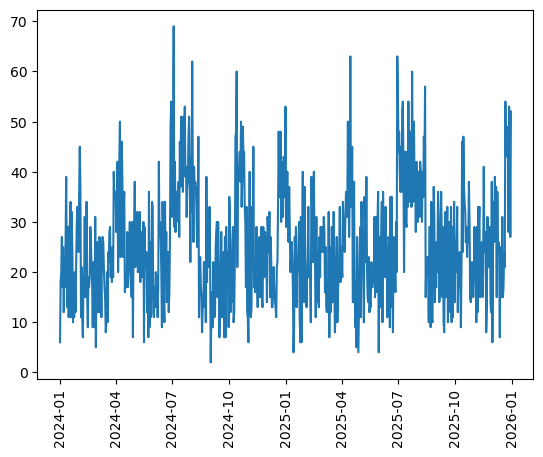

In [10]:
df_gla = df_catering[df_catering['Route'] == 'GLA-DXB']
plt.plot(df_gla['Flight_Date'],df_gla['CHML_Ordered'])
plt.xticks(rotation=90)
plt.show()

In [11]:
df_catering.drop(['Load_Factor', 'Demand_Lambda_Used'], axis=1, inplace = True)

df_catering.to_csv('data/raw_data.csv')